<a href="https://colab.research.google.com/github/loukikjoshi06-ops/SIH-26016/blob/main/AI_Model/notebooks/01_qwen2_5_vl_3b_qlora_colab_kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
!nvidia-smi


Sat Sep  5 17:42:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P0             30W /   70W |    7547MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [38]:
!pip install -q git+https://github.com/huggingface/transformers
!pip install -q accelerate bitsandbytes peft qwen-vl-utils trl torchvision


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [39]:
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

# 1. 4-bit Quantization Config (saves memory, ~2.5 GB VRAM)
compute_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

# 2. Processor with resolution caps to prevent VRAM spikes
processor = AutoProcessor.from_pretrained(
    model_id,
    min_pixels=256 * 28 * 28,
    max_pixels=1280 * 28 * 28
)

# 3. Download & load model into GPU
print("Downloading and loading Qwen2.5-VL-3B in 4-bit...")
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    device_map="auto",
    torch_dtype=compute_dtype,
    quantization_config=quantization_config
)
print("✅ Model loaded successfully into Colab GPU!")


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

✅ Model loaded successfully into Colab GPU!


In [40]:
from datasets import load_dataset

# Download the Marathi Handwritten dataset
dataset = load_dataset("Process-Venue/Marathi_Handwritten")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'id', 'filename', 'label', 'type'],
        num_rows: 2016
    })
    validation: Dataset({
        features: ['image', 'id', 'filename', 'label', 'type'],
        num_rows: 504
    })
})


ID: 2360
Filename: 2360.png
Label (correct Marathi text): ले
Type: Barakhadi


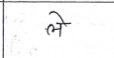

In [41]:
# Look at the first training example
sample = dataset["train"][0]

print("ID:", sample["id"])
print("Filename:", sample["filename"])
print("Label (correct Marathi text):", sample["label"])
print("Type:", sample["type"])

# Show the actual handwritten image
sample["image"]

Sample 0: ले


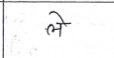

---
Sample 1: मैफिल


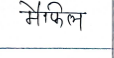

---
Sample 2: वोट


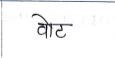

---
Sample 3: इह


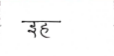

---
Sample 4: बडोदा


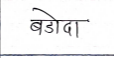

---


In [42]:
# See 5 examples
for i in range(5):
    sample = dataset["train"][i]
    print(f"Sample {i}: {sample['label']}")
    display(sample["image"])
    print("---")

In [43]:
!pip install -q peft trl

cell 4

In [44]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 37,152,768 || all params: 3,791,775,744 || trainable%: 0.9798


cell 5 prepare the data

In [50]:
train_ds = dataset["train"]
val_ds   = dataset["validation"]

print("✅ Dataset ready!")
print("Train size:", len(train_ds))
print("Val size:  ", len(val_ds))

✅ Dataset ready!
Train size: 2016
Val size:   504


cell 6 collector = Prepares Data for Training

In [51]:
def collate_fn(examples):
    texts = []
    all_images = []

    for ex in examples:
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": ex["image"]},
                    {"type": "text",  "text": "Read the handwritten Marathi text in this image and transcribe it exactly."}
                ]
            },
            {
                "role": "assistant",
                "content": ex["label"]
            }
        ]

        text = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )
        texts.append(text)
        all_images.append(ex["image"])

    batch = processor(
        text=texts,
        images=all_images,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    )

    labels = batch["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    batch["labels"] = labels
    return batch

print("✅ Collator ready!")

✅ Collator ready!


In [54]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir="./marathi-ocr-model",
    num_train_epochs=1,                # ← reduced from 3 to 1
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,     # ← reduced from 8 to 4
    learning_rate=2e-4,
    warmup_steps=20,                   # ← reduced from 50 to 20
    lr_scheduler_type="cosine",
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    report_to="none",
    remove_unused_columns=False,
    dataloader_num_workers=0,
    max_length=256,                    # ← reduced from 512 to 256
)

print("✅ Faster training config ready!")

✅ Faster training config ready!


In [55]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collate_fn,
)

print("🚀 Starting training...")
trainer.train()
print("✅ Training complete!")

🚀 Starting training...


/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:957: UserWarning: inner dimension (3420) is not aligned for fast kernel with blocksize=64, falling back to slower implementation.
  warn(


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
50,6.808080,6.811151,6.895935,63747.000000,0.120696
100,6.804962,6.799757,6.892167,127551.000000,0.121427


/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:957: UserWarning: inner dimension (3420) is not aligned for fast kernel with blocksize=64, falling back to slower implementation.
  warn(
/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:957: UserWarning: inner dimension (3420) is not aligned for fast kernel with blocksize=64, falling back to slower implementation.
  warn(


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
50,6.808080,6.811151,6.895935,63747.000000,0.120696
100,6.804962,6.799757,6.892167,127551.000000,0.121427


KeyboardInterrupt: 

In [56]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Mounted at /content/drive
✅ Drive mounted!


In [57]:
model.save_pretrained("/content/drive/MyDrive/marathi-ocr-model/lora_adapter")
processor.save_pretrained("/content/drive/MyDrive/marathi-ocr-model/lora_adapter")
print("✅ Model saved!")

✅ Model saved!
